# Урок 15.17. Комбинаторика: искусство считать варианты

**Интерактивная версия:** `lessons/lesson_15_17/web/index.html`

Каждую формулу урока проверяем двумя способами: формулой и перебором (`itertools`), а там, где это
возможно, — ещё и библиотекой (`math`, `scipy.special`, `scipy.stats`, scikit-learn).

1. Правила подсчёта: сумма, произведение, случаи, дополнение, деление; сетка и кандидаты в разбиения.
2. Перестановки, размещения, сочетания, анаграммы, пути по решётке; насколько велик $n!$.
3. Треугольник Паскаля, бином, тождества двойного подсчёта, $\log_2\binom{n}{k} \approx nH(k/n)$.
4. Ящики и разбиения: звёзды и перегородки, неравновероятные мультимножества, числа Стирлинга и Белла.
5. Мощные приёмы: включения-исключения, беспорядки, рекуррентности, Каталан, производящие функции.
6. От подсчёта к вероятности: гипергеометрическое распределение, дни рождения, бутстрэп, купоны, перестановочный тест.
7. Комбинаторика в бустинге: разбиения категорий (теорема Фишера), бутстрэп в случайном лесу, значения Шепли.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import math
from collections import Counter
from fractions import Fraction
from itertools import combinations, combinations_with_replacement, permutations, product

import matplotlib.pyplot as plt
import numpy as np
from scipy import special, stats

from gbcourse.plotting import use_course_style
from gbcourse.rng import Mulberry32
from gbcourse.style import AQUA, BLUE, MUTED, ORANGE, RED

use_course_style()
comb, perm, factorial = math.comb, math.perm, math.factorial

## 1. Правила подсчёта

**Сумма** — для непересекающихся случаев, **произведение** — для этапов, у которых число вариантов не
зависит от прошлых выборов. Если зависит — делим на случаи. Проверим примеры урока перебором.

In [2]:
nums = range(100, 1000)
distinct = [n for n in nums if len(set(str(n))) == 3]
even = [n for n in distinct if n % 2 == 0]
print("пароли из 1–3 букв:", 26 + 26**2 + 26**3)
print("трёхзначные с разными цифрами:", len(distinct), "= 9·9·8 =", 9 * 9 * 8)
print("из них чётных:", len(even), "= 9·8 + 4·8·8 =", 9 * 8 + 4 * 8 * 8)
print("кратных 2 или 3 до 100:", sum(1 for i in range(1, 101) if i % 2 == 0 or i % 3 == 0), "= 50 + 33 − 16")
assert len(distinct) == 648 and len(even) == 328

# Дополнение: PIN-коды
pins = list(product(range(10), repeat=4))
print("PIN с семёркой:", sum(7 in p for p in pins), "= 10⁴ − 9⁴ =", 10**4 - 9**4)
print("PIN с повтором:", sum(len(set(p)) < 4 for p in pins), "= 10⁴ − 10·9·8·7 =", 10**4 - perm(10, 4))
print("де Мере: 4 кубика", round(1 - (5 / 6) ** 4, 4), " 24 пары кубиков", round(1 - (35 / 36) ** 24, 4))

# Деление: круглый стол и пары
canon = lambda s: min(s[i:] + s[:i] for i in range(len(s)))
print("рассадок 6 человек за круглым столом:", len({canon(p) for p in permutations(range(6))}), "= 5! =", factorial(5))
pairings = {frozenset(frozenset(p[i:i + 2]) for i in range(0, 6, 2)) for p in permutations(range(6))}
print("разбиений 6 человек на пары:", len(pairings), "= 6!/(2!³·3!) =", factorial(6) // (8 * 6))

пароли из 1–3 букв: 18278
трёхзначные с разными цифрами: 648 = 9·9·8 = 648
из них чётных: 328 = 9·8 + 4·8·8 = 328
кратных 2 или 3 до 100: 67 = 50 + 33 − 16
PIN с семёркой: 3439 = 10⁴ − 9⁴ = 3439
PIN с повтором: 4960 = 10⁴ − 10·9·8·7 = 4960
де Мере: 4 кубика 0.5177  24 пары кубиков 0.4914
рассадок 6 человек за круглым столом: 120 = 5! = 120
разбиений 6 человек на пары: 15 = 6!/(2!³·3!) = 15


### Правило произведения в бустинге: сетка и пороги

Сетка гиперпараметров растёт как произведение числа значений. Число порогов на уровне $l$ дерева:
точный перебор — $p(n - 2^l)$, гистограммы — не больше $2^l p (B - 1)$.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


144 комбинаций; × 5 фолдов = 720 обучений; по 2 с — 24.0 мин
n = 10⁶, p = 100, глубина 6: точно 6e+08, гистограммы 1,606,500 — в 373 раз меньше


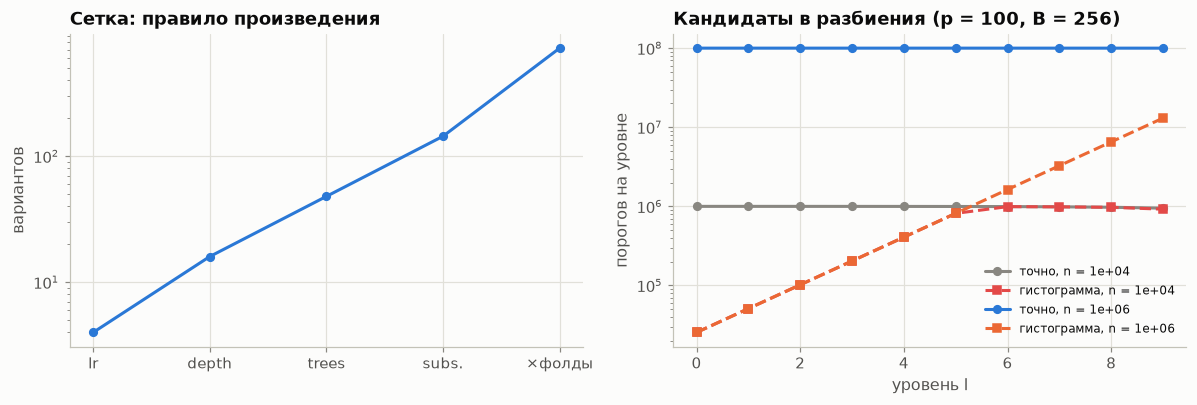

In [3]:
grid = {"learning_rate": [0.03, 0.05, 0.1, 0.2], "max_depth": [3, 4, 5, 6], "n_estimators": [100, 300, 1000], "subsample": [0.6, 0.8, 1.0]}
combos = list(product(*grid.values()))
print(len(combos), "комбинаций; × 5 фолдов =", len(combos) * 5, "обучений; по 2 с —", len(combos) * 5 * 2 / 60, "мин")

n, p, B, d = 10**6, 100, 256, 6
levels = [(lev, p * (n - 2**lev), 2**lev * p * min(n // 2**lev - 1, B - 1)) for lev in range(d)]
exact, hist = sum(e for _, e, _ in levels), sum(h for _, _, h in levels)
print(f"n = 10⁶, p = 100, глубина 6: точно {exact:.3g}, гистограммы {hist:,} — в {exact / hist:.0f} раз меньше")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
vals = [len(v) for v in grid.values()] + [5]
axes[0].plot(range(1, 6), np.cumprod(vals), "o-", color=BLUE)
axes[0].set(yscale="log", xticks=range(1, 6), xticklabels=["lr", "depth", "trees", "subs.", "×фолды"], ylabel="вариантов", title="Сетка: правило произведения")
for nn, c in ((10**4, MUTED), (10**6, BLUE)):
    ls = range(10)
    axes[1].plot(ls, [p * (nn - 2**lev) for lev in ls], "o-", color=c, label=f"точно, n = {nn:.0e}")
    axes[1].plot(ls, [2**lev * p * min(nn // 2**lev - 1, B - 1) for lev in ls], "s--", color=ORANGE if nn == 10**6 else RED, label=f"гистограмма, n = {nn:.0e}")
axes[1].set(yscale="log", xlabel="уровень l", ylabel="порогов на уровне", title="Кандидаты в разбиения (p = 100, B = 256)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 2. Перестановки, размещения, сочетания

Таблица «порядок × повторения» — формулы против `itertools`.

In [4]:
items, k = "ABCDE", 3
n = len(items)
table = {
    "размещения": (perm(n, k), len(list(permutations(items, k)))),
    "сочетания": (comb(n, k), len(list(combinations(items, k)))),
    "слова": (n**k, len(list(product(items, repeat=k)))),
    "с повторениями без порядка": (comb(n + k - 1, k), len(list(combinations_with_replacement(items, k)))),
}
for name, (f, b) in table.items():
    print(f"{name:28s} формула {f:4d}  перебор {b:4d}")
    assert f == b

for w in ("МАМА", "ПАПАХА", "МИССИСИПИ", "КОМБИНАТОРИКА"):
    c = Counter(w)
    formula = factorial(len(w)) // math.prod(factorial(v) for v in c.values())
    brute = len(set(permutations(w))) if len(w) <= 9 else "—"
    print(f"{w:14s} {formula:>12,}  перебор: {brute}")
print("10 объектов по фолдам 4/3/3:", factorial(10) // (factorial(4) * factorial(3) ** 2))
print("12 объектов на 3 непомеченные группы по 4:", factorial(12) // factorial(4) ** 3 // factorial(3))
print("комиссия с хотя бы одной женщиной:", sum(any(x >= 6 for x in c) for c in combinations(range(10), 3)), "=", comb(10, 3) - comb(6, 3))

размещения                   формула   60  перебор   60
сочетания                    формула   10  перебор   10
слова                        формула  125  перебор  125
с повторениями без порядка   формула   35  перебор   35
МАМА                      6  перебор: 6
ПАПАХА                   60  перебор: 60
МИССИСИПИ             2,520  перебор: 2520
КОМБИНАТОРИКА   389,188,800  перебор: —
10 объектов по фолдам 4/3/3: 4200
12 объектов на 3 непомеченные группы по 4: 5775
комиссия с хотя бы одной женщиной: 100 = 100


### Пути по решётке и динамическое программирование

In [5]:
def lattice(m, n, blocked=()):
    T = [[0] * (n + 1) for _ in range(m + 1)]
    for x in range(m + 1):
        for y in range(n + 1):
            if (x, y) not in blocked:
                T[x][y] = 1 if x == y == 0 else (T[x - 1][y] if x else 0) + (T[x][y - 1] if y else 0)
    return T[m][n]


print("сетка 4×3:", lattice(4, 3), "= C(7, 3) =", comb(7, 3), "; в обход (2, 1):", lattice(4, 3, {(2, 1)}), "= 35 − 3·6")

сетка 4×3: 35 = C(7, 3) = 35 ; в обход (2, 1): 17 = 35 − 3·6


### Насколько велик $n!$: Стирлинг, цифры, нули

    5! — цифр     3, нулей в конце    1, ошибка Стирлинга 1.65069% (1/(12n) = 1.66667%)
   10! — цифр     7, нулей в конце    2, ошибка Стирлинга 0.82960% (1/(12n) = 0.83333%)
   20! — цифр    19, нулей в конце    4, ошибка Стирлинга 0.41577% (1/(12n) = 0.41667%)
   52! — цифр    68, нулей в конце   12, ошибка Стирлинга 0.16013% (1/(12n) = 0.16026%)
  100! — цифр   158, нулей в конце   24, ошибка Стирлинга 0.08330% (1/(12n) = 0.08333%)
 1000! — цифр  2568, нулей в конце  249, ошибка Стирлинга 0.00833% (1/(12n) = 0.00833%)
10! секунд = 42.0 суток


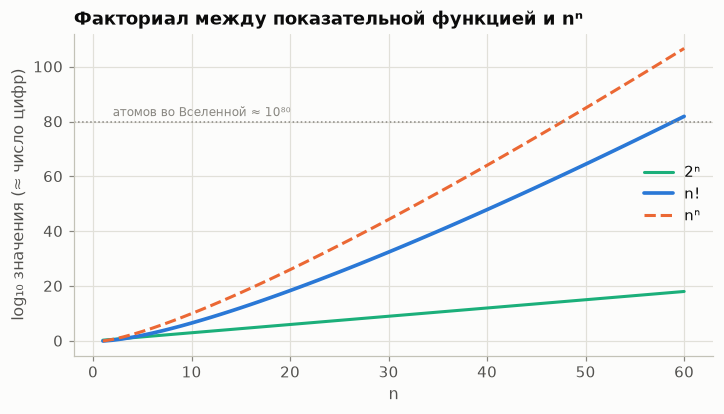

In [6]:
for n in (5, 10, 20, 52, 100, 1000):
    lnst = 0.5 * math.log(2 * math.pi * n) + n * (math.log(n) - 1)
    err = 1 - math.exp(lnst - math.lgamma(n + 1))
    zeros = sum(n // 5**i for i in range(1, 10))
    print(f"{n:5}! — цифр {len(str(factorial(n))):5}, нулей в конце {zeros:4}, ошибка Стирлинга {err:.5%} (1/(12n) = {1 / (12 * n):.5%})")
print("10! секунд =", factorial(10) / 86400, "суток")

ns = np.arange(1, 61)
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.plot(ns, ns * np.log10(2), color=AQUA, label="2ⁿ")
ax.plot(ns, [math.lgamma(n + 1) / math.log(10) for n in ns], color=BLUE, lw=2.4, label="n!")
ax.plot(ns, ns * np.log10(ns), "--", color=ORANGE, label="nⁿ")
ax.axhline(80, color=MUTED, ls=":", lw=1)
ax.text(2, 82, "атомов во Вселенной ≈ 10⁸⁰", fontsize=8, color=MUTED)
ax.set(xlabel="n", ylabel="log₁₀ значения (≈ число цифр)", title="Факториал между показательной функцией и nⁿ")
ax.legend()
plt.show()

## 3. Треугольник Паскаля, бином и тождества

                              1                             
                            1   1                           
                          1   2   1                         
                        1   3   3   1                       
                      1   4   6   4   1                     
                    1   5  10  10   5   1                   
                  1   6  15  20  15   6   1                 
                1   7  21  35  35  21   7   1               
нечётных в строке 10: 4 = 2^(единиц в 1010₂) = 4
коэффициент при x³ в (2x − 1)⁵: 80
1.01¹⁰⁰: 2.7048138294215285  первые 6 слагаемых бинома: 2.703441002
Вандермонд: 120 120  клюшка: 56 56  капитан: 360 360  квадраты: 924 924
log₂ C(1000, 100) = 464.4, 1000·H(0.1) = 469.0
C(20, 10) = 184756, 2²⁰·√(2/(20π)) = 187079
P(ровно 50 орлов из 100) = 0.0796


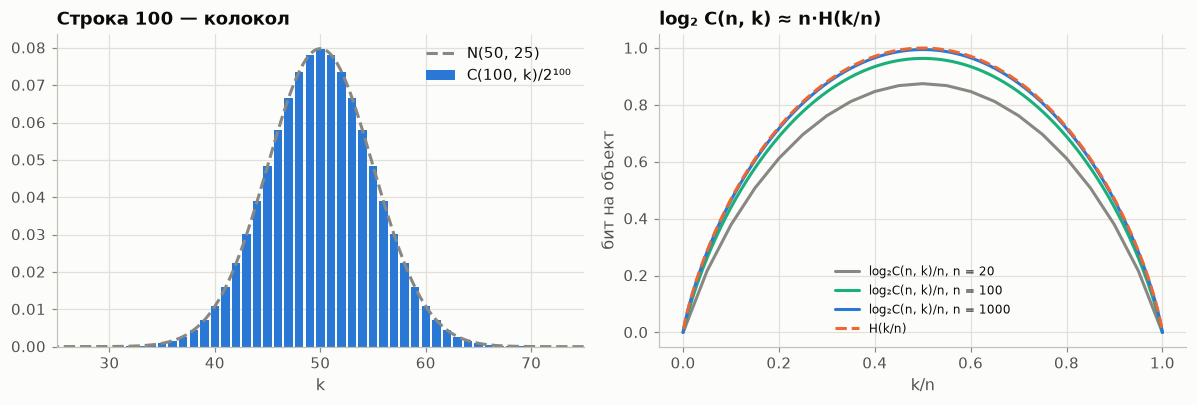

In [7]:
row = [1]
rows = [row]
for _n in range(1, 13):
    row = [a + b for a, b in zip([0] + row, row + [0])]
    rows.append(row)
for n in range(8):
    print(" ".join(f"{c:3}" for c in rows[n]).center(60))
assert all(rows[n][k] == comb(n, k) for n in range(13) for k in range(n + 1))
print("нечётных в строке 10:", sum(c % 2 for c in rows[10]), "= 2^(единиц в 1010₂) =", 2 ** bin(10).count("1"))
print("коэффициент при x³ в (2x − 1)⁵:", comb(5, 3) * 2**3 * (-1) ** 2)
print("1.01¹⁰⁰:", 1.01**100, " первые 6 слагаемых бинома:", sum(comb(100, k) * 0.01**k for k in range(6)))
print("Вандермонд:", sum(comb(6, j) * comb(4, 3 - j) for j in range(4)), comb(10, 3),
      " клюшка:", sum(comb(i, 2) for i in range(2, 8)), comb(8, 3),
      " капитан:", 3 * comb(10, 3), 10 * comb(9, 2),
      " квадраты:", sum(comb(6, j) ** 2 for j in range(7)), comb(12, 6))

H = lambda q: 0.0 if q in (0, 1) else -q * math.log2(q) - (1 - q) * math.log2(1 - q)
print(f"log₂ C(1000, 100) = {math.log2(comb(1000, 100)):.1f}, 1000·H(0.1) = {1000 * H(0.1):.1f}")
print(f"C(20, 10) = {comb(20, 10)}, 2²⁰·√(2/(20π)) = {2**20 * math.sqrt(2 / (20 * math.pi)):.0f}")
print(f"P(ровно 50 орлов из 100) = {comb(100, 50) / 2**100:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
n = 100
ks = np.arange(n + 1)
axes[0].bar(ks, [comb(n, k) / 2**n for k in ks], color=BLUE, width=0.8, label="C(100, k)/2¹⁰⁰")
xs = np.linspace(0, n, 400)
axes[0].plot(xs, stats.norm(n / 2, math.sqrt(n) / 2).pdf(xs), "--", color=MUTED, label="N(50, 25)")
axes[0].set(xlim=(25, 75), xlabel="k", title="Строка 100 — колокол")
axes[0].legend()
for n, c in ((20, MUTED), (100, AQUA), (1000, BLUE)):
    axes[1].plot(np.arange(n + 1) / n, [math.log2(comb(n, k)) / n for k in range(n + 1)], color=c, label=f"log₂C(n, k)/n, n = {n}")
qs = np.linspace(0.001, 0.999, 300)
axes[1].plot(qs, [H(q) for q in qs], "--", color=ORANGE, label="H(k/n)")
axes[1].set(xlabel="k/n", ylabel="бит на объект", title="log₂ C(n, k) ≈ n·H(k/n)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. Ящики и разбиения

Звёзды и перегородки, целые решения, неравновероятные мультимножества, числа Стирлинга и Белла.

In [8]:
print("мороженое 3 из 5:", comb(7, 3), " домино:", comb(8, 2), " бутстрэп n = 10:", comb(19, 10), "из", 10**10)
sols = lambda n, k, lo=0, hi=None: sum(1 for t in product(range(lo, (hi if hi is not None else k) + 1), repeat=n) if sum(t) == k)
print("10 конфет 3 детям:", sols(3, 10), comb(12, 2), "| каждому ≥ 1:", sols(3, 10, 1), comb(9, 2),
      "| никому > 4:", sols(3, 10, 0, 4), comb(12, 2) - 3 * comb(7, 2) + 3 * comb(2, 2))

# Мультимножества неравновероятны
for n in (3, 4):
    c = Counter(tuple(sorted(t)) for t in product(range(n), repeat=n))
    print(f"бутстрэп из {n}: исходов {len(c)} = C({2 * n - 1}, {n}); вероятности от {Fraction(min(c.values()), n**n)} до {Fraction(max(c.values()), n**n)}")
two = Counter(tuple(sorted(t)) for t in product(range(1, 7), repeat=2))
print("два кубика: P{5,6} =", Fraction(two[(5, 6)], 36), " P{6,6} =", Fraction(two[(6, 6)], 36))
print("бутстрэп из 10 без повторов:", factorial(10) / 10**10)


def set_partitions(items):
    if not items:
        yield []
        return
    first, rest = items[0], items[1:]
    for p in set_partitions(rest):
        yield [[first]] + p
        for i in range(len(p)):
            yield p[:i] + [[first] + p[i]] + p[i + 1:]


for n in range(1, 8):
    P = list(set_partitions(list(range(n))))
    by_r = Counter(len(p) for p in P)
    assert all(by_r[r] == special.stirling2(n, r, exact=True) for r in range(1, n + 1))
    print(f"n = {n}: Белл {len(P):4}, S(n, r) = {[by_r[r] for r in range(1, n + 1)]}")
print("S(k, 2) = 2^(k−1) − 1:", all(special.stirling2(k, 2, exact=True) == 2 ** (k - 1) - 1 for k in range(2, 15)))
print("сюръекции 5 → 3:", 6 * special.stirling2(5, 3, exact=True), "=", sum(len(set(f)) == 3 for f in product(range(3), repeat=5)))

мороженое 3 из 5: 35  домино: 28  бутстрэп n = 10: 92378 из 10000000000
10 конфет 3 детям: 66 66 | каждому ≥ 1: 36 36 | никому > 4: 6 6
бутстрэп из 3: исходов 10 = C(5, 3); вероятности от 1/27 до 2/9
бутстрэп из 4: исходов 35 = C(7, 4); вероятности от 1/256 до 3/32
два кубика: P{5,6} = 1/18  P{6,6} = 1/36
бутстрэп из 10 без повторов: 0.00036288
n = 1: Белл    1, S(n, r) = [1]
n = 2: Белл    2, S(n, r) = [1, 1]
n = 3: Белл    5, S(n, r) = [1, 3, 1]
n = 4: Белл   15, S(n, r) = [1, 7, 6, 1]
n = 5: Белл   52, S(n, r) = [1, 15, 25, 10, 1]
n = 6: Белл  203, S(n, r) = [1, 31, 90, 65, 15, 1]
n = 7: Белл  877, S(n, r) = [1, 63, 301, 350, 140, 21, 1]
S(k, 2) = 2^(k−1) − 1: True
сюръекции 5 → 3: 150 = 150


## 5. Мощные приёмы

In [9]:
N = 100
ie = N // 2 + N // 3 + N // 5 - N // 6 - N // 10 - N // 15 + N // 30
print("кратных 2, 3 или 5:", ie, "| слова длины 6 со всеми буквами abc:", sum(len(set(w)) == 3 for w in product("abc", repeat=6)), "= 3⁶ − 3·2⁶ + 3 =", 3**6 - 3 * 2**6 + 3)

der = [1, 0]
for m in range(2, 13):
    der.append((m - 1) * (der[-1] + der[-2]))
for n in (4, 5, 7):
    assert der[n] == sum(all(p[i] != i for i in range(n)) for p in permutations(range(n)))
print("беспорядки:", der[:11], "; доля при n = 10:", der[10] / factorial(10), "1/e =", 1 / math.e)

rng = Mulberry32(1)
fixed = [sum(v == i for i, v in enumerate(rng.permutation(10))) for _ in range(5000)]
fc = Counter(fixed)
print("совпадения при n = 10, 5000 раскладок:", {j: round(fc[j] / 5000, 3) for j in range(5)}, " Пуассон(1):", [round(float(stats.poisson(1).pmf(j)), 3) for j in range(5)], " среднее", np.mean(fixed))

T = [1, 1]
for _i in range(2, 31):
    T.append(T[-1] + T[-2])
no11 = sum("11" not in "".join(map(str, t)) for t in product((0, 1), repeat=5))
print("замощения n = 4:", T[4], " лестница 10:", T[10], " строки без «11» длины 5:", no11, " T(30)/T(29):", T[30] / T[29])

catalan = [comb(2 * n, n) // (n + 1) for n in range(10)]


def shapes(n):
    return ["x"] if n == 0 else [f"({L}{R})" for i in range(n) for L in shapes(i) for R in shapes(n - 1 - i)]


print("Каталан:", catalan, " перебор форм:", [len(shapes(n)) for n in range(7)])

die = np.array([0] + [1] * 6)
three = np.convolve(np.convolve(die, die), die)
coins = np.zeros(11, int)
coins[0] = 1
for c in (1, 2, 5):
    q = np.zeros(11, int)
    q[::c] = 1
    coins = np.convolve(coins, q)[:11]
print("три кубика: сумма 9 —", three[9], ", 10 —", three[10], "| размен 10 монетами 1, 2, 5:", coins[10])

кратных 2, 3 или 5: 74 | слова длины 6 со всеми буквами abc: 540 = 3⁶ − 3·2⁶ + 3 = 540
беспорядки: [1, 0, 1, 2, 9, 44, 265, 1854, 14833, 133496, 1334961] ; доля при n = 10: 0.3678794642857143 1/e = 0.36787944117144233
совпадения при n = 10, 5000 раскладок: {0: 0.365, 1: 0.371, 2: 0.185, 3: 0.062, 4: 0.014}  Пуассон(1): [0.368, 0.368, 0.184, 0.061, 0.015]  среднее 0.9984
замощения n = 4: 5  лестница 10: 89  строки без «11» длины 5: 13  T(30)/T(29): 1.6180339887505408
Каталан: [1, 1, 2, 5, 14, 42, 132, 429, 1430, 4862]  перебор форм: [1, 1, 2, 5, 14, 42, 132]
три кубика: сумма 9 — 25 , 10 — 27 | размен 10 монетами 1, 2, 5: 10


## 6. От подсчёта к вероятности

фолд 100 из 1000 (50 положительных): P(X ≤ 2) = 0.1056 (биномиальное 0.1183), P(X ≥ 9) = 0.0531
лотерея 6 из 45, ровно 3: 0.02244059589493509 = 0.022440595894935092
урна 20/8, взяли 5, ровно 2 белых: 0.3973
положительных в 10 случайных фолдах: [4, 4, 4, 3, 6, 5, 10, 8, 2, 4]  (стратификация дала бы ровно по 5)
дни рождения, n = 23: точно 0.5073, приближённо 0.5000
дни рождения, n = 30: точно 0.7063, приближённо 0.6963
дни рождения, n = 57: точно 0.9901, приближённо 0.9874
32-битный хеш, 50 %: 77163 ключей


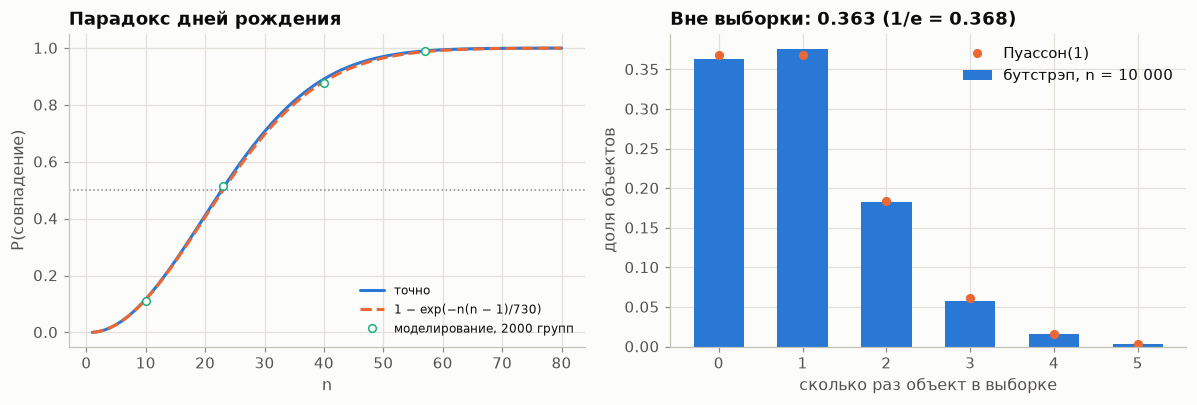

купоны, n = 10: в среднем 29.1 выборов (300 опытов), формула n·Hₙ = 29.3
купоны, n = 100: в среднем 510.6 выборов (300 опытов), формула n·Hₙ = 518.7
деревьев, чтобы у всех 10 000 объектов был OOB-прогноз (ожидаемо < 1 без него): 21


In [10]:
hg = stats.hypergeom(1000, 50, 100)
print(f"фолд 100 из 1000 (50 положительных): P(X ≤ 2) = {hg.cdf(2):.4f} (биномиальное {stats.binom(100, 0.05).cdf(2):.4f}), P(X ≥ 9) = {hg.sf(8):.4f}")
print("лотерея 6 из 45, ровно 3:", comb(6, 3) * comb(39, 3) / comb(45, 6), "=", stats.hypergeom(45, 6, 6).pmf(3))
print("урна 20/8, взяли 5, ровно 2 белых:", round(stats.hypergeom(20, 8, 5).pmf(2), 4))

# Стратификация: сколько положительных в фолдах
y = np.zeros(1000, int)
y[:50] = 1
idx = Mulberry32(3).permutation(1000)
folds = [int(y[idx[i::10]].sum()) for i in range(10)]
print("положительных в 10 случайных фолдах:", folds, " (стратификация дала бы ровно по 5)")

pd_ = lambda n, D=365: math.prod((D - i) / D for i in range(n))
for n in (23, 30, 57):
    print(f"дни рождения, n = {n}: точно {1 - pd_(n):.4f}, приближённо {1 - math.exp(-n * (n - 1) / 730):.4f}")
print("32-битный хеш, 50 %:", round(math.sqrt(2 * 2**32 * math.log(2))), "ключей")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
ns = np.arange(1, 81)
axes[0].plot(ns, [1 - pd_(n) for n in ns], color=BLUE, lw=2, label="точно")
axes[0].plot(ns, 1 - np.exp(-ns * (ns - 1) / 730), "--", color=ORANGE, label="1 − exp(−n(n − 1)/730)")
sim_n = [10, 23, 40, 57]
sim = []
for n in sim_n:
    r = Mulberry32(n)
    sim.append(sum(len({r.randint(365) for _ in range(n)}) < n for _ in range(2000)) / 2000)
axes[0].plot(sim_n, sim, "o", mfc="white", color=AQUA, label="моделирование, 2000 групп")
axes[0].axhline(0.5, color=MUTED, ls=":", lw=1)
axes[0].set(xlabel="n", ylabel="P(совпадение)", title="Парадокс дней рождения")
axes[0].legend(fontsize=8)

# Бутстрэп: число попаданий объекта
n = 10000
cnt = Counter(Mulberry32(7).bootstrap(n))
freq = Counter(cnt.get(i, 0) for i in range(n))
ks = np.arange(6)
axes[1].bar(ks, [freq[k] / n for k in ks], color=BLUE, width=0.6, label="бутстрэп, n = 10 000")
axes[1].plot(ks, stats.poisson(1).pmf(ks), "o", color=ORANGE, label="Пуассон(1)")
axes[1].set(xlabel="сколько раз объект в выборке", ylabel="доля объектов", title=f"Вне выборки: {freq[0] / n:.3f} (1/e = {1 / math.e:.3f})")
axes[1].legend()
plt.tight_layout()
plt.show()

# Собиратель купонов
for n in (10, 100):
    runs = []
    for seed in range(300):
        r, seen, t = Mulberry32(seed + 1), set(), 0
        while len(seen) < n:
            seen.add(r.randint(n))
            t += 1
        runs.append(t)
    print(f"купоны, n = {n}: в среднем {np.mean(runs):.1f} выборов (300 опытов), формула n·Hₙ = {n * sum(1 / i for i in range(1, n + 1)):.1f}")
print("деревьев, чтобы у всех 10 000 объектов был OOB-прогноз (ожидаемо < 1 без него):", math.ceil(math.log(10000) / -math.log(1 - 1 / math.e)))

### Перестановочный тест: точный перебор против SciPy

In [11]:
r = Mulberry32(3)
a = [round(r.normal(0, 1) * 100) / 100 for _ in range(5)]
b = [round(r.normal(1, 1) * 100) / 100 for _ in range(5)]
x = a + b
obs = abs(np.mean(b) - np.mean(a))
diffs = [abs((sum(x) - sum(x[i] for i in S)) / 5 - sum(x[i] for i in S) / 5) for S in combinations(range(10), 5)]
p_exact = np.mean([d >= obs - 1e-9 for d in diffs])
res = stats.permutation_test((b, a), lambda u, v: abs(np.mean(u) - np.mean(v)), permutation_type="independent", alternative="greater", n_resamples=10**6)
print(f"раздач {len(diffs)}, точное p = {p_exact:.4f}, scipy = {res.pvalue:.4f}; наименьшее возможное двустороннее p = {2 / 252:.4f}")
assert abs(p_exact - res.pvalue) < 1e-12

раздач 252, точное p = 0.3333, scipy = 0.3333; наименьшее возможное двустороннее p = 0.0079


## 7. Комбинаторика в бустинге

**Теорема Фишера:** при квадратичной потере лучшее разбиение категорий — префикс порядка по среднему.
Проверим на 50 случайных наборах по 8 категорий: $2^7 - 1 = 127$ разбиений против 7 префиксов.

In [12]:
def make_cats(k, seed):
    rng = Mulberry32(seed)
    return [(chr(65 + i), 5 + rng.randint(26), rng.normal(0, 1)) for i in range(k)]


def gain(cats, left):
    L = [c for c in cats if c[0] in left]
    R = [c for c in cats if c[0] not in left]
    nL, nR = sum(c[1] for c in L), sum(c[1] for c in R)
    mL = sum(c[1] * c[2] for c in L) / nL
    mR = sum(c[1] * c[2] for c in R) / nR
    return nL * nR / (nL + nR) * (mL - mR) ** 2


agree = 0
for seed in range(1, 51):
    cats = make_cats(8, seed)
    names = [c[0] for c in cats]
    splits = [set(("A",) + rest) for r_ in range(len(names) - 1) for rest in combinations(names[1:], r_)]
    best = max(gain(cats, s) for s in splits)
    order = [c[0] for c in sorted(cats, key=lambda c: c[2])]
    agree += math.isclose(best, max(gain(cats, set(order[:i])) for i in range(1, len(names))))
print(f"разбиений {len(splits)}, лучшее — префикс в {agree} из 50 наборов")
assert agree == 50

разбиений 127, лучшее — префикс в 50 из 50 наборов


**Бутстрэп в случайном лесе.** `RandomForestRegressor` хранит индексы выборок деревьев — доля объектов вне
каждой выборки должна быть около $1/e$, а доля объектов, не вошедших ни в одну из $M$ выборок, — около $e^{-M}$.

In [13]:
from sklearn.ensemble import RandomForestRegressor

rng_np = np.random.default_rng(0)
X = rng_np.normal(size=(2000, 3))
yy = X[:, 0] + rng_np.normal(size=2000)
rf = RandomForestRegressor(n_estimators=50, max_depth=3, random_state=0).fit(X, yy)
in_bag = np.zeros((50, 2000), bool)
for t, s in enumerate(rf.estimators_samples_):
    in_bag[t, np.unique(s)] = True
print("доля вне выборки по деревьям:", round(1 - in_bag.mean(), 4), " 1/e =", round(1 / math.e, 4))
print("ни в одной из первых 3 выборок:", round((~in_bag[:3]).all(0).mean(), 4), " e⁻³ =", round(math.exp(-3), 4))

доля вне выборки по деревьям: 0.3695  1/e = 0.3679
ни в одной из первых 3 выборок: 0.051  e⁻³ = 0.0498


**Значения Шепли.** Веса — доли порядков; точный расчёт перебирает $2^M$ коалиций, приближение — $R$ случайных
порядков с ошибкой $\propto 1/\sqrt{R}$. Модель-игра с попарными взаимодействиями имеет и формулу
$\varphi_j = a_j + \frac12\sum_k b_{jk}$.

сумма значений: 7.958456 = v(все) − v(∅) = 7.958456


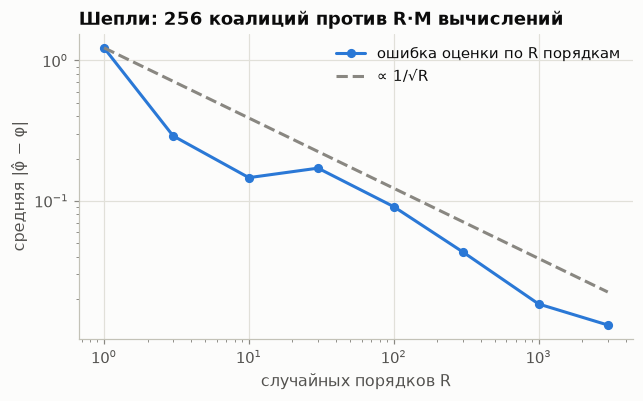

ошибки: {1: 1.2295, 3: 0.2902, 10: 0.1463, 30: 0.171, 100: 0.0909, 300: 0.0433, 1000: 0.0184, 3000: 0.0131}


In [14]:
M = 8
r = Mulberry32(2)
a = [r.normal(0, 1) for _ in range(M)]
bmat = [[0.0] * M for _ in range(M)]
for i in range(M):
    for j in range(i + 1, M):
        bmat[i][j] = bmat[j][i] = r.normal(0, 0.7)
v = lambda S: sum(a[i] for i in S) + sum(bmat[i][j] for i, j in combinations(sorted(S), 2))
exact = [sum(factorial(len(S)) * factorial(M - len(S) - 1) / factorial(M) * (v(set(S) | {j}) - v(set(S)))
             for r_ in range(M) for S in combinations([i for i in range(M) if i != j], r_)) for j in range(M)]
formula = [a[j] + 0.5 * sum(bmat[j]) for j in range(M)]
assert np.allclose(exact, formula)
print("сумма значений:", round(sum(exact), 6), "= v(все) − v(∅) =", round(v(set(range(M))), 6))

r2 = Mulberry32(102)
acc, Rs, errs = np.zeros(M), [], []
for t in range(1, 3001):
    S, prev = set(), 0.0
    for j in r2.permutation(M):
        S.add(j)
        cur = v(S)
        acc[j] += cur - prev
        prev = cur
    if t in (1, 3, 10, 30, 100, 300, 1000, 3000):
        Rs.append(t)
        errs.append(np.mean(np.abs(acc / t - exact)))
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.loglog(Rs, errs, "o-", color=BLUE, label="ошибка оценки по R порядкам")
ax.loglog(Rs, errs[0] / np.sqrt(Rs), "--", color=MUTED, label="∝ 1/√R")
ax.set(xlabel="случайных порядков R", ylabel="средняя |φ̂ − φ|", title=f"Шепли: {2**M} коалиций против R·M вычислений")
ax.legend()
plt.show()
print("ошибки:", {R: round(float(e), 4) for R, e in zip(Rs, errs)})

## Упражнения

Задания — в `exercises/tasks.md`, решения — в `exercises/solutions.py`.